<a href="https://colab.research.google.com/github/MartinSomsak00/MLF/blob/main/project_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === BLOK 1: Knihovny a připojení k Google Drive ===

# Instalace tuneru pro hledání optimální architektury
!pip install -q -U keras-tuner

# Běžné importy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import random

# ML framework – TensorFlow (Keras)
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Připojení Google Disku
from google.colab import drive
drive.mount('/content/drive')

# Cesta k datům na disku
data_path = '/content/drive/MyDrive/MPA-MLF_DATA_NEW'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.0 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# === BLOK 2: Načtení trénovacích dat a přiřazení štítků ===

# Cesty ke složkám s trénovacími daty
train_files = sorted(
    glob.glob(f'{data_path}/Train/*.npy'),
    key=lambda x: int(x.split('/')[-1].split('.')[0])
)

# Načtení dat do jednoho NumPy pole
X_all = np.array([np.load(file) for file in train_files])
print(f"Načteno {X_all.shape[0]} trénovacích vzorků ve tvaru {X_all.shape[1:]}")

# Načtení souboru s cílovými hodnotami (štítky)
labels_df = pd.read_csv(f'{data_path}/label_train.csv')
print("Ukázka načtených štítků:")
print(labels_df.head())

# Extrakce pole s třídami
y_all = labels_df['target'].values
print(f"Počet štítků: {len(y_all)}")


Načteno 1491 trénovacích vzorků ve tvaru (72, 48)
Ukázka načtených štítků:
   ID  target
0   0       0
1   1       0
2   2       0
3   3       0
4   4       0
Počet štítků: 1491


In [3]:
# === BLOK 3: Normalizace, reshaping a rozdělení dat ===

# Normalizace (standardizace): vzorek po vzorku – každému zvlášť průměr 0, std 1
X_all = (X_all - X_all.mean(axis=(1, 2), keepdims=True)) / X_all.std(axis=(1, 2), keepdims=True)

# Rozdělení dat – 80 % na trénink, 20 % na validaci (vyvážené dle tříd)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print(f"Trénovací sada: {X_train.shape[0]} vzorků")
print(f"Validační sada: {X_val.shape[0]} vzorků")

# Přidání rozměru pro "kanál" (72, 48) → (72, 48, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

# One-hot encoding pro 3 třídy
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val, num_classes=3)


Trénovací sada: 1192 vzorků
Validační sada: 299 vzorků


In [4]:
# === BLOK 4: Návrh CNN modelu s možností ladění ===

# Funkce pro konstrukci modelu, který budeme ladit pomocí tuneru
def navrhni_model(nastaveni):
    cnn = models.Sequential()

    # První konvoluční vrstva
    cnn.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(72, 48, 1),
                          kernel_regularizer=regularizers.l2(1e-4)))
    cnn.add(layers.BatchNormalization())
    cnn.add(LeakyReLU(alpha=0.1))
    cnn.add(layers.MaxPooling2D((2, 2)))
    cnn.add(layers.Dropout(0.25))

    # Druhá konvoluční vrstva
    cnn.add(layers.Conv2D(64, (3, 3), padding='same',
                          kernel_regularizer=regularizers.l2(1e-4)))
    cnn.add(layers.BatchNormalization())
    cnn.add(LeakyReLU(alpha=0.1))
    cnn.add(layers.MaxPooling2D((2, 2)))
    cnn.add(layers.Dropout(0.25))

    # Hustá vrstva
    pocet_neuronu = nastaveni.Int('dense_units', min_value=128, max_value=512, step=64)
    cnn.add(layers.Flatten())
    cnn.add(layers.Dense(pocet_neuronu, kernel_regularizer=regularizers.l2(1e-4)))
    cnn.add(layers.BatchNormalization())
    cnn.add(LeakyReLU(alpha=0.1))

    # Dropout vrstva
    dropout_val = nastaveni.Float('dropout', min_value=0.4, max_value=0.7, step=0.1)
    cnn.add(layers.Dropout(dropout_val))

    # Výstup – 3 třídy, softmax
    cnn.add(layers.Dense(3, activation='softmax'))

    # Laditelná learning rate
    lr = nastaveni.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    return cnn


In [5]:
# === BLOK 5: Spuštění Keras Tuneru a výběr nejlepší architektury ===

# Nastavení tuneru – Random Search přes 10 různých kombinací
tuner = kt.RandomSearch(
    hypermodel=navrhni_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory='tunovani_modelu',
    project_name='cnn_klasifikace'
)

# Shrnutí laditelných parametrů
tuner.search_space_summary()

# Spuštění procesu ladění
tuner.search(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=32,
    verbose=2
)

# Získání nejlepšího modelu podle validace
nejlepsi_model = tuner.get_best_models(num_models=1)[0]

# Shrnutí výsledků a architektury
tuner.results_summary()
nejlepsi_model.summary()


Trial 10 Complete [00h 00m 25s]
val_accuracy: 0.9933110475540161

Best val_accuracy So Far: 0.9933110475540161
Total elapsed time: 00h 04m 44s
Results summary
Results in tunovani_modelu/cnn_klasifikace
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
dense_units: 512
dropout: 0.4
learning_rate: 0.00332265556312533
Score: 0.9933110475540161

Trial 03 summary
Hyperparameters:
dense_units: 512
dropout: 0.6000000000000001
learning_rate: 0.003921412901411757
Score: 0.9933110475540161

Trial 04 summary
Hyperparameters:
dense_units: 128
dropout: 0.4
learning_rate: 0.0017311246306854196
Score: 0.9933110475540161

Trial 05 summary
Hyperparameters:
dense_units: 128
dropout: 0.4
learning_rate: 0.007765767620141046
Score: 0.9933110475540161

Trial 07 summary
Hyperparameters:
dense_units: 448
dropout: 0.5
learning_rate: 0.003366336681373164
Score: 0.9933110475540161

Trial 08 summary
Hyperparameters:
dense_units: 256
dropout: 0.5
learning_rat

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 72, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 72, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 72, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 36, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 36, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     7,078,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,101,187 (27.09 MB)

 Trainable params: 7,099,971 (27.08 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [6]:
# === BLOK 6: Trénink finálního modelu s checkpointem ===

# Uložení nejlepší váhové konfigurace modelu podle validační ztráty
zachovej_model = ModelCheckpoint(
    'nejlepsi_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Trénink modelu – 50 epoch, batch size 32
historie = nejlepsi_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[zachovej_model],
    verbose=2
)


Epoch 1/50

Epoch 1: val_loss improved from inf to 0.38779, saving model to nejlepsi_model.h5


38/38 - 15s - 391ms/step - accuracy: 0.9866 - loss: 0.3530 - val_accuracy: 0.9933 - val_loss: 0.3878
Epoch 2/50

Epoch 2: val_loss did not improve from 0.38779
38/38 - 0s - 11ms/step - accuracy: 0.9849 - loss: 0.4258 - val_accuracy: 0.9900 - val_loss: 0.4371
Epoch 3/50

Epoch 3: val_loss improved from 0.38779 to 0.34984, saving model to nejlepsi_model.h5


38/38 - 1s - 17ms/step - accuracy: 0.9924 - loss: 0.3831 - val_accuracy: 0.9933 - val_loss: 0.3498
Epoch 4/50

Epoch 4: val_loss improved from 0.34984 to 0.32901, saving model to nejlepsi_model.h5


38/38 - 1s - 16ms/step - accuracy: 0.9950 - loss: 0.3058 - val_accuracy: 0.9900 - val_loss: 0.3290
Epoch 5/50

Epoch 5: val_loss did not improve from 0.32901
38/38 - 0s - 10ms/step - accuracy: 0.9883 - loss: 0.3962 - val_accuracy: 0.9833 - val_loss: 0.4340
Epoch 6/50

Epoch 6: val_loss did not improve from 0.32901
38/38 - 0s - 10ms/step - accuracy: 0.9815 - loss: 0.4870 - val_accuracy: 0.9565 - val_loss: 0.5755
Epoch 7/50

Epoch 7: val_loss did not improve from 0.32901
38/38 - 0s - 10ms/step - accuracy: 0.9849 - loss: 0.5467 - val_accuracy: 0.8930 - val_loss: 2.2584
Epoch 8/50

Epoch 8: val_loss did not improve from 0.32901
38/38 - 0s - 10ms/step - accuracy: 0.9891 - loss: 0.6870 - val_accuracy: 0.8294 - val_loss: 2.5872
Epoch 9/50

Epoch 9: val_loss did not improve from 0.32901
38/38 - 1s - 16ms/step - accuracy: 0.9891 - loss: 0.7721 - val_accuracy: 0.8997 - val_loss: 1.1337
Epoch 10/50

Epoch 10: val_loss did not improve from 0.32901
38/38 - 0s - 10ms/step - accuracy: 0.9899 - loss: 

38/38 - 1s - 17ms/step - accuracy: 0.9975 - loss: 0.2989 - val_accuracy: 0.9900 - val_loss: 0.3102
Epoch 19/50

Epoch 19: val_loss improved from 0.31022 to 0.29566, saving model to nejlepsi_model.h5


38/38 - 1s - 33ms/step - accuracy: 0.9958 - loss: 0.2705 - val_accuracy: 0.9866 - val_loss: 0.2957
Epoch 20/50

Epoch 20: val_loss did not improve from 0.29566
38/38 - 0s - 10ms/step - accuracy: 0.9958 - loss: 0.3535 - val_accuracy: 0.9900 - val_loss: 0.4237
Epoch 21/50

Epoch 21: val_loss did not improve from 0.29566
38/38 - 1s - 16ms/step - accuracy: 0.9975 - loss: 0.3736 - val_accuracy: 0.9900 - val_loss: 0.3728
Epoch 22/50

Epoch 22: val_loss did not improve from 0.29566
38/38 - 1s - 16ms/step - accuracy: 0.9992 - loss: 0.3245 - val_accuracy: 0.9900 - val_loss: 0.3076
Epoch 23/50

Epoch 23: val_loss did not improve from 0.29566
38/38 - 0s - 10ms/step - accuracy: 0.9883 - loss: 0.4063 - val_accuracy: 0.9866 - val_loss: 0.5237
Epoch 24/50

Epoch 24: val_loss did not improve from 0.29566
38/38 - 0s - 10ms/step - accuracy: 0.9958 - loss: 0.4079 - val_accuracy: 0.9900 - val_loss: 0.3951
Epoch 25/50

Epoch 25: val_loss did not improve from 0.29566
38/38 - 1s - 16ms/step - accuracy: 0.997

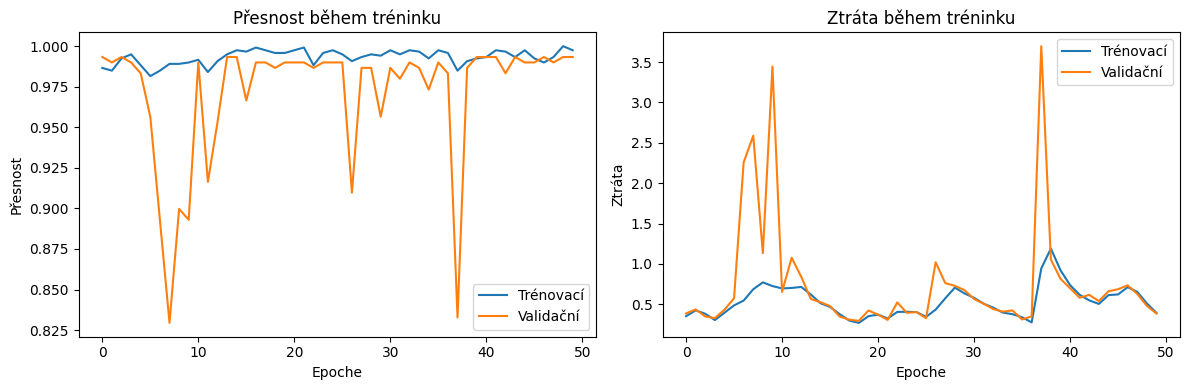

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step


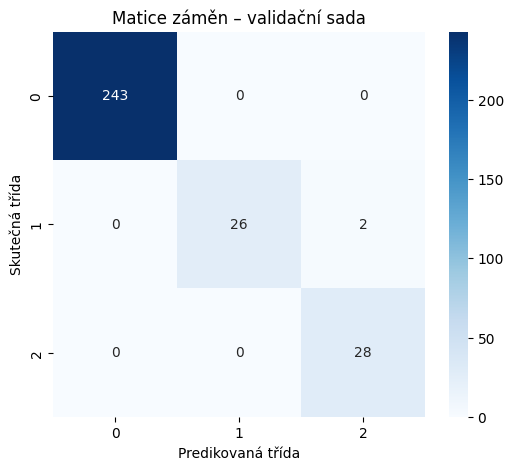

Klasifikační zpráva:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       243
           1     1.0000    0.9286    0.9630        28
           2     0.9333    1.0000    0.9655        28

    accuracy                         0.9933       299
   macro avg     0.9778    0.9762    0.9762       299
weighted avg     0.9938    0.9933    0.9933       299



In [7]:
# === BLOK 7: Vyhodnocení – grafy, matice záměn, klasifikační zpráva ===

# Zobrazení průběhu tréninku – přesnost a ztráta
plt.figure(figsize=(12, 4))

# Přesnost
plt.subplot(1, 2, 1)
plt.plot(historie.history['accuracy'], label='Trénovací')
plt.plot(historie.history['val_accuracy'], label='Validační')
plt.title('Přesnost během tréninku')
plt.xlabel('Epoche'); plt.ylabel('Přesnost'); plt.legend()

# Ztráta
plt.subplot(1, 2, 2)
plt.plot(historie.history['loss'], label='Trénovací')
plt.plot(historie.history['val_loss'], label='Validační')
plt.title('Ztráta během tréninku')
plt.xlabel('Epoche'); plt.ylabel('Ztráta'); plt.legend()

plt.tight_layout()
plt.show()

# Predikce tříd pro validační data
y_val_pred_probs = nejlepsi_model.predict(X_val)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

# Matice záměn
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel('Predikovaná třída')
plt.ylabel('Skutečná třída')
plt.title('Matice záměn – validační sada')
plt.show()

# Výpis klasifikační zprávy
print("Klasifikační zpráva:")
print(classification_report(y_val_true, y_val_pred, digits=4))


In [8]:
# === BLOK 8: Načtení a příprava testovacích vzorků ===

# Filtrování a seřazení testovacích souborů podle názvu (ID)
test_files = glob.glob(f'{data_path}/Test/*.npy')
test_files = sorted(
    [f for f in test_files if re.fullmatch(r".*/\d+\.npy", f)],
    key=lambda x: int(x.split('/')[-1].split('.')[0])
)

# Načtení a normalizace testovacích vzorků
X_test = np.array([np.load(f) for f in test_files])
X_test = (X_test - X_test.mean(axis=(1, 2), keepdims=True)) / X_test.std(axis=(1, 2), keepdims=True)

# Přidání rozměru pro CNN
X_test = X_test[..., np.newaxis]

print(f"Testovací data načtena: {X_test.shape}")


Testovací data načtena: (120, 72, 48, 1)


In [9]:
# === BLOK 9: Predikce na testovacích datech a export do submission.csv ===

# Pro získání správného pořadí ID použijeme test_format.csv
format_df = pd.read_csv(f'{data_path}/test_format.csv')

# Predikce pravděpodobností pro každou třídu
test_pred_probs = nejlepsi_model.predict(X_test)

# Výběr nejpravděpodobnější třídy (0, 1 nebo 2)
test_pred_classes = np.argmax(test_pred_probs, axis=1)

# Zkopírování vzoru souboru a doplnění predikcí
vysledky_df = format_df.copy()
vysledky_df['target'] = test_pred_classes

# Uložení výsledného souboru
vysledky_df.to_csv('submission.csv', index=False)

print("Soubor 'submission.csv' byl vytvořen.")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step
Soubor 'submission.csv' byl vytvořen. Můžeš ho nahrát na Kaggle.
